In [ ]:
# Importing userdata to ensure confidentiality of Kaggle API token and take from Colab secrets
# Ensure kaggle is installed as a data source for this project: dataco smart supply chain dataset for big data analysis

import os
from google.colab import userdata
!pip install -q kaggle
os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')
!kaggle datasets download -d shashwatwork/dataco-smart-supply-chain-for-big-data-analysis

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis
License(s): CC0-1.0
100% 25.7M/25.7M [00:00<00:00, 161MB/s]



In [ ]:
#importing all the necessary libraries for the required ML modelling including sci-kit learn libraries
#importing logistics regression, randomforestclassifier and XGBoost for Prediction of Delivery Delays
#importing KMeans to see any meaningful clusters in the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    silhouette_score, davies_bouldin_score, mean_squared_error, r2_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import OneHotEncoder # for onehotencoding
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")
print(f"✓ Random seed set to {RANDOM_STATE}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")

✓ All libraries imported successfully!
✓ Random seed set to 42
✓ NumPy version: 2.0.2
✓ Pandas version: 2.2.2


In [ ]:
#unzipping the DataCo Supply Chain Dataset to load it into pandas DataFrame
import zipfile
with zipfile.ZipFile('dataco-smart-supply-chain-for-big-data-analysis.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataco')
import os
os.listdir('/content/dataco')

# Show all columns
pd.set_option('display.max_columns', None)
# Optional: Show full width of each column
pd.set_option('display.max_colwidth', None)
# Optional: Prevent line wrapping
pd.set_option('display.expand_frame_repr', False)
df = pd.read_csv('/content/dataco/DataCoSupplyChainDataset.csv',
                 encoding='latin1')

#the following verifies and do a quick check of the dataset
#this also drops columns that are deemed irrelevant with the desired analysis and outcome
df.shape
df.columns
df.info()
df = df.drop(["Category Id",
        "Customer Email",
        "Customer Fname",
        "Customer Lname",
        "Customer Password",
        "Customer Id",
        "Department Id",
        "Latitude",
        "Longitude",
        "Order Customer Id",
        "Order Id",
        "Order Item Id",
        "Order Item Cardprod Id",
        "Product Category Id",
        "Product Card Id"],axis = 1)

#counting the count of shipments/orders with late delivery risk to assess any further need for class imbalance handling
df['Late_delivery_risk'].value_counts(normalize=True)
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"{col} ({df[col].nunique()} unique values)")
    print(df[col].unique())

summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2),
    "Unique Values": df.nunique()
})
summary.sort_values("Unique Values")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

,Data Type,Missing,Missing (%),Unique Values
Product Description,float64,180519,100.00,0
Product Status,int64,0,0.00,1
Customer Country,object,0,0.00,2
Late_delivery_risk,int64,0,0.00,2
Customer Segment,object,0,0.00,3
Delivery Status,object,0,0.00,4
Type,object,0,0.00,4
Days for shipment (scheduled),int64,0,0.00,4
Shipping Mode,object,0,0.00,4
Market,object,0,0.00,5


In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Name,Market,Order City,Order Country,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,5365 Noble Nectar Island,725.0,Fitness,Pacific Asia,Bekasi,Indonesia,1/31/2018 22:56,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,2679 Rustic Loop,725.0,Fitness,Pacific Asia,Bikaner,India,1/13/2018 12:27,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,Consumer,CA,8510 Round Bear Gate,95125.0,Fitness,Pacific Asia,Bikaner,India,1/13/2018 12:06,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,Home Office,CA,3200 Amber Bend,90027.0,Fitness,Pacific Asia,Townsville,Australia,1/13/2018 11:45,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,Corporate,PR,8671 Iron Anchor Corners,725.0,Fitness,Pacific Asia,Townsville,Australia,1/13/2018 11:24,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
#cleaning data and handling missing value by replacing with median values
df = df.drop_duplicates().reset_index(drop=True)
for col in ['Sales', 'Product Price']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

#handling outliers by capping extreme sales skewness via IQR method
Q1, Q3 = df['Sales'].quantile(0.25), df['Sales'].quantile(0.75)
IQR = Q3 - Q1
df['Sales'] = np.clip(df['Sales'], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

#engineering features and calculating shipping delay variances by comparing real versus planned/scheduled days of delivery
df['Shipping_Delay_Variance'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# Feature Binning: Segment sales into equal quantiles
df['Sales_Volume_Bin'] = pd.qcut(df['Sales'], q=3, labels=['Low_Value', 'Medium_Value', 'High_Value'])

# Column transformation array mapping (Scaling & Encoding)
num_pipeline_features = ['Sales', 'Product Price', 'Shipping_Delay_Variance']
cat_pipeline_features = ['Shipping Mode', 'Type', 'Sales_Volume_Bin']

#creating preprocessing timeline for numerical and categorical features.
#numerical features are standardizewd using z-scale normalization
#categorical features are transformed into binary indicator variables using hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_pipeline_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_pipeline_features)
    ]
)
processed_matrix = preprocessor.fit_transform(df)
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_pipeline_features)
all_feature_names = list(num_pipeline_features) + list(encoded_cat_names)

X = pd.DataFrame(processed_matrix, columns=all_feature_names)
y = df['Late_delivery_risk']

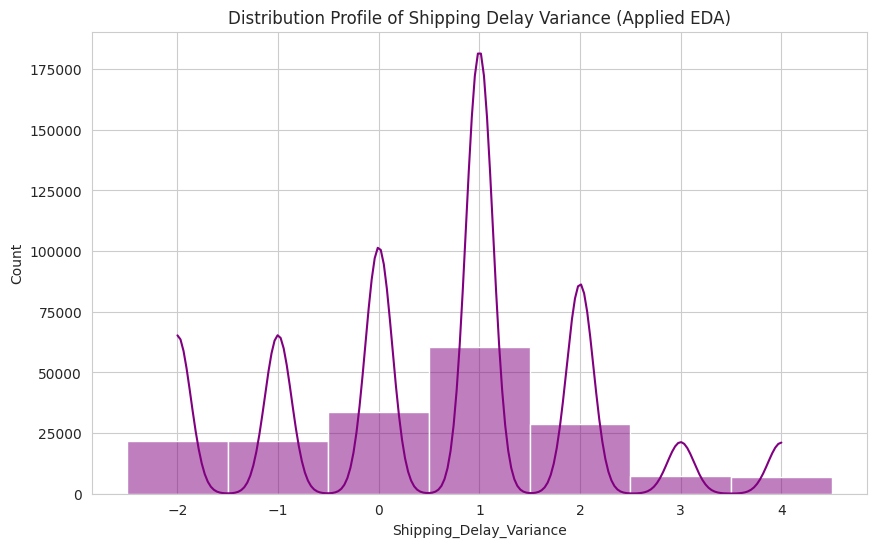

In [ ]:
#EDA

# Plot Distribution & Relationship to check frequency of shipments encountering particular number of days in delay
plt.figure()
sns.histplot(data=df, x='Shipping_Delay_Variance', kde=True, discrete=True, color='purple')
plt.title('Distribution Profile of Shipping Delay Variance (Applied EDA)')
plt.show()



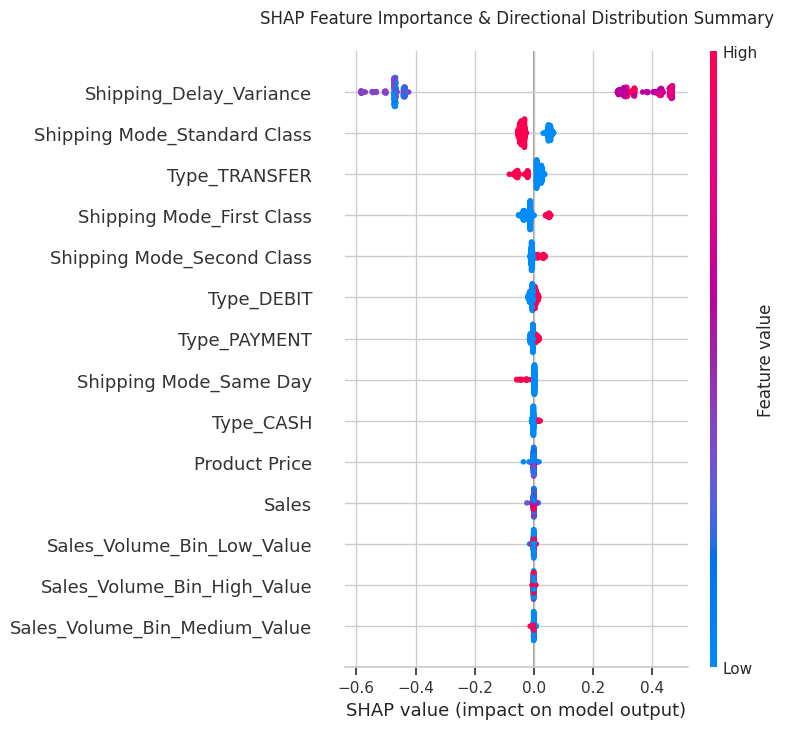

Feature Selection Step: Reduced footprint from 14 down to 10 features.


In [ ]:
#Performing SHAP for feature importance and explainability
# Train model base to extract patterns for SHAP
# Ensure xgboost is installed: !pip install xgboost shap
from xgboost import XGBClassifier
import shap

# Set up global plotting configurations
sns.set_theme(style="whitegrid")

baseline_model = RandomForestClassifier(n_estimators=50, max_depth=12, random_state=42)
baseline_model.fit(X, y)

explainer = shap.TreeExplainer(baseline_model)
X_sample_for_shap = X.sample(n=min(500, len(X)), random_state=42)
shap_values = explainer(X_sample_for_shap)
if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]  # Target risk class = 1

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample_for_shap, show=False)
plt.title('SHAP Feature Importance & Directional Distribution Summary', fontsize=12, pad=20)
plt.show()

global_shap_importance = np.abs(shap_values.values).mean(axis=0)
shap_importance_series = pd.Series(global_shap_importance, index=X.columns)
# Adjusted threshold to retain more features
shap_filtering_threshold = shap_importance_series.quantile(0.25)
selected_features = shap_importance_series[shap_importance_series >= shap_filtering_threshold].index.tolist()

X_selected = X[selected_features]
print(f"Feature Selection Step: Reduced footprint from {X.shape[1]} down to {X_selected.shape[1]} features.")

PCA Summary: Explaining 64.25% variance on 2D mapping.


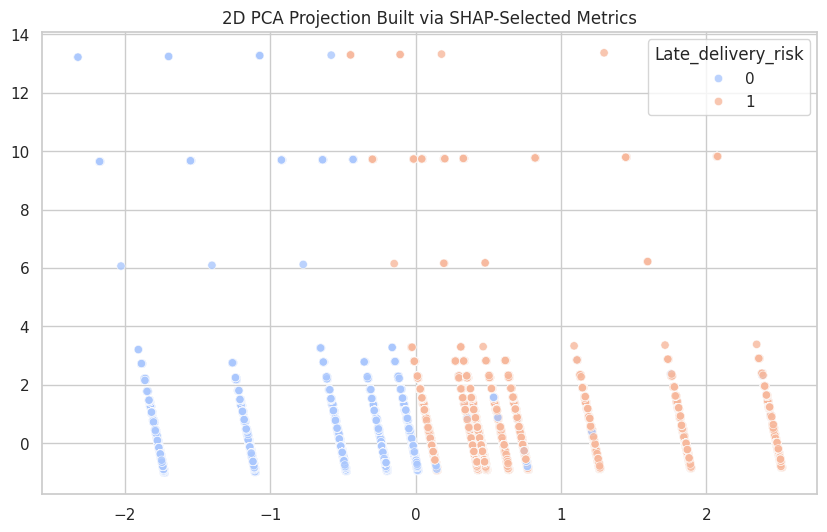

In [ ]:
#reducing dimensionality using PCA to minimize principal component features while retaining maximum variance possible
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(X_selected)
print(f"PCA Summary: Explaining {np.sum(pca.explained_variance_ratio_)*100:.2f}% variance on 2D mapping.")

plt.figure()
sns.scatterplot(x=pca_results[:, 0], y=pca_results[:, 1], hue=y, palette='coolwarm', alpha=0.8)
plt.title('2D PCA Projection Built via SHAP-Selected Metrics')
plt.show()

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(X_selected)

# Create a DataFrame with PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X_selected.columns
)

# Look at the top influential features for PC1 and PC2. Intent is to understand what feature is driving the 2 principal components
print("--- Top Features Driving PC1 ---")
print(loadings['PC1'].sort_values(ascending=False).head(5))

print("\n--- Top Features Driving PC2 ---")
print(loadings['PC2'].sort_values(ascending=False).head(5))

--- Top Features Driving PC1 ---
Shipping_Delay_Variance       0.933169
Shipping Mode_Second Class    0.213812
Shipping Mode_First Class     0.062073
Type_PAYMENT                  0.004132
Shipping Mode_Same Day        0.003146
Name: PC1, dtype: float64

--- Top Features Driving PC2 ---
Product Price                 0.999124
Shipping_Delay_Variance       0.039494
Shipping Mode_Second Class    0.008706
Shipping Mode_First Class     0.003002
Type_CASH                     0.001384
Name: PC2, dtype: float64


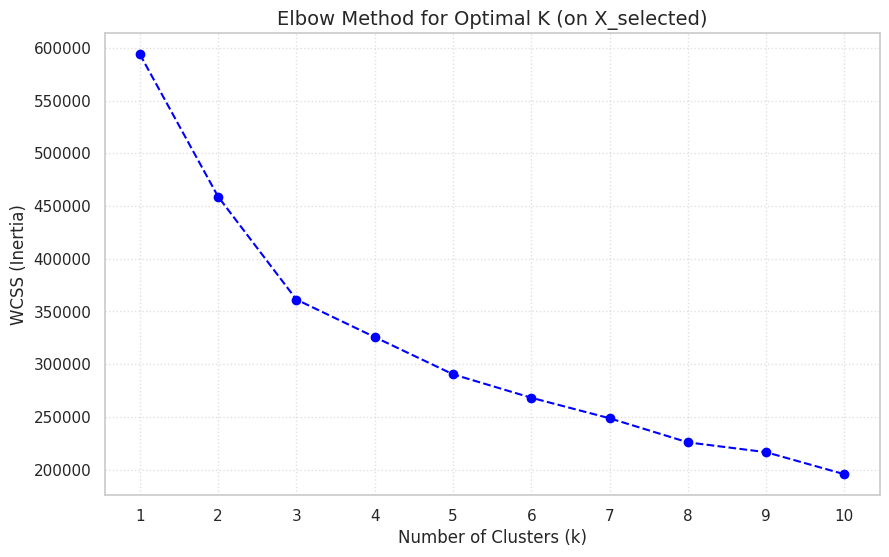

Selected Optimal K: 3
Cluster distribution:
Cluster
1    93384
2    54042
0    33093
Name: count, dtype: int64

Late Delivery Risk distribution per Cluster:


Late_delivery_risk,0,1
Cluster,,
0,0.425558,0.574442
1,0.143676,0.856324
2,1.000000,0.000000


,Sales,Product Price,Shipping_Delay_Variance
Cluster,,,
0,365.515774,378.735666,0.648929
1,162.786684,85.448182,1.462992
2,167.454275,92.190634,-1.035417


In [ ]:
#Applying clustering techniques to identify natural groupings or segments within our data based on the relevant characteristics identified using SHAP
# We will use X_selected for clustering, as it contains all preprocessed features.
# X_selected already has numerical features scaled and categorical features one-hot encoded.

# Determine optimal number of clusters using the Elbow Method
wcss = [] # Within-Cluster Sum of Squares
k_range = range(1, 11) # Checking for 1 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_selected)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method for Optimal K (on X_selected)', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Based on the elbow plot, choose an optimal k (e.g., 3 or 4 based on typical elbow points)
optimal_k = 3 # This is an example, adjust based on the plot
print(f"Selected Optimal K: {optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_selected)

# Add cluster labels to the original DataFrame
df['Cluster'] = clusters

print("Cluster distribution:")
print(df['Cluster'].value_counts())

# Analyze cluster characteristics regarding late delivery risk
print("\nLate Delivery Risk distribution per Cluster:")
cluster_risk_summary = df.groupby('Cluster')['Late_delivery_risk'].value_counts(normalize=True).unstack().fillna(0)
display(cluster_risk_summary)

# Visualize mean feature values per cluster (for interpretation)
cluster_means = df.groupby('Cluster')[['Sales', 'Product Price', 'Shipping_Delay_Variance']].mean()
display(cluster_means)

In [ ]:
# =====================================================================
# REST OF LIFECYCLE (Train-Test Split, Model Training, & Forecasting)
# =====================================================================
# Doing 80-20 split between training and test dataset and stratifying to ensure data proportions are retained in both training and test dataset
print("\n--- CONTINUING DOWNSTREAM LIFECYCLE STEPS ---")
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)


--- CONTINUING DOWNSTREAM LIFECYCLE STEPS ---


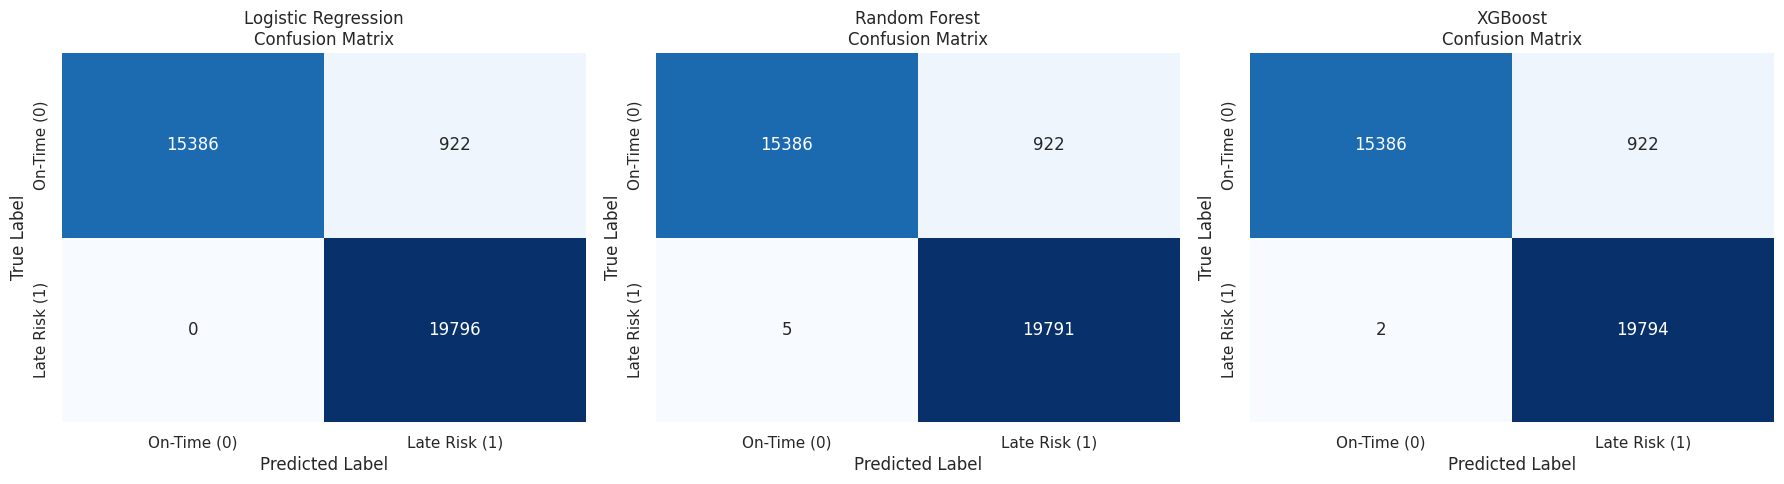


========== SIDE-BY-SIDE MODEL COMPARISON ==========
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.974463   0.955498 1.000000  0.977242 0.982036
      Random Forest  0.974324   0.955487 0.999747  0.977116 0.993411
            XGBoost  0.974407   0.955493 0.999899  0.977192 0.993404


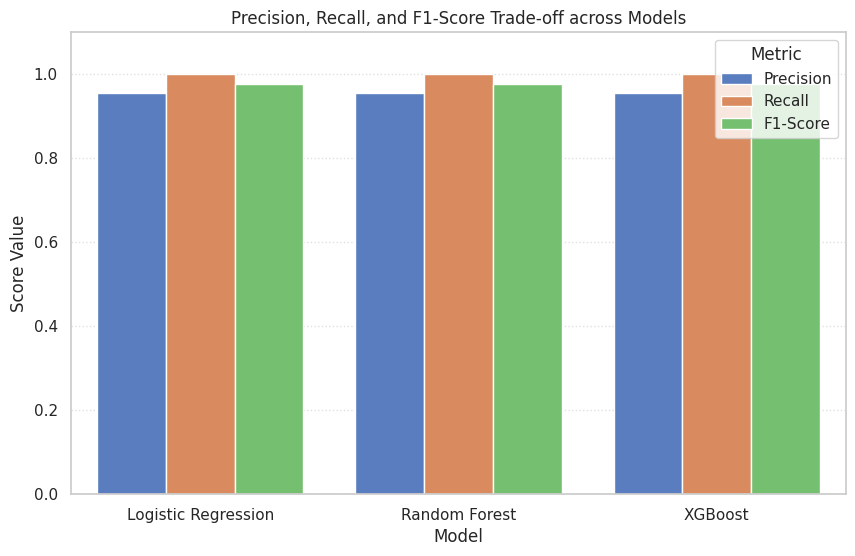

In [ ]:
# Initialize the models. Testing out and comparing performance metrics across three different models suitable for classification problems
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')
}

# Create Dictionary to store performance metrics
metrics_summary = []

# Set up a multi-plot figure for Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (model_name, model) in enumerate(models.items()):
    # Train the model
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Needed for ROC-AUC

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Append results to list
    metrics_summary.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['On-Time (0)', 'Late Risk (1)'],
                yticklabels=['On-Time (0)', 'Late Risk (1)'])
    axes[i].set_title(f'{model_name}\nConfusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# 4. Convert summary to a DataFrame and display it
df_metrics = pd.DataFrame(metrics_summary)
print("\n========== SIDE-BY-SIDE MODEL COMPARISON ==========")
print(df_metrics.to_string(index=False))

#Visual comparison plot for Precision vs Recall
df_melted = df_metrics.melt(id_vars='Model', value_vars=['Precision', 'Recall', 'F1-Score'],
                            var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='muted')
plt.title('Precision, Recall, and F1-Score Trade-off across Models')
plt.ylim(0, 1.1)
plt.ylabel('Score Value')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()


--- Running SHAP Analysis on Champion Model: Logistic Regression ---


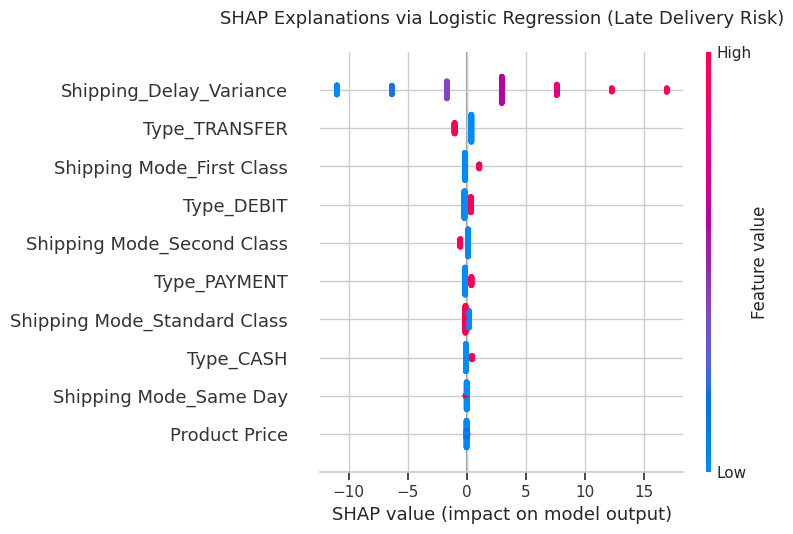

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END .......................max_depth=3, n_estimators=10; total time=   0.1s
[CV] END .......................max_depth=3, n_estimators=10; total time=   0.1s
[CV] END .......................max_depth=3, n_estimators=10; total time=   0.1s
GridSearchCV completed. Best risk model extracted.


In [ ]:

#SELECT CHAMPION MODEL & RUN ADAPTIVE SHAP ANALYSIS
# =====================================================================
# We automatically extract the best performing model from our F1 run to evaluate with SHAP
f1_series = df_metrics.set_index('Model')['F1-Score'].sort_values(ascending=False)
best_model_name = f1_series.index[0]
best_model = models[best_model_name]
print(f"\n--- Running SHAP Analysis on Champion Model: {best_model_name} ---")

# Memory Optimization: Sample rows carefully from the selected feature footprint
X_sample_for_shap = X_train.sample(n=min(300, len(X_train)), random_state=42)

# Dynamic Explainer Assignment based on the algorithm type
if best_model_name in ["Random Forest", "XGBoost"]:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_sample_for_shap)
elif best_model_name == "Logistic Regression":
    explainer = shap.LinearExplainer(best_model, X_sample_for_shap)
    shap_values = explainer(X_sample_for_shap)

# Standardize output indexing arrays across varied algorithm formats
if hasattr(shap_values, "shape") and len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]  # Target risk class = 1 (Delayed)

# Render Global SHAP Summary Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample_for_shap, show=False)
plt.title(f'SHAP Explanations via {best_model_name} (Late Delivery Risk)', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

# Retrain Model & Hyperparameter Tuning
tuned_rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=tuned_rf, param_grid={'n_estimators': [10], 'max_depth': [3]}, cv=3, scoring='accuracy', n_jobs=1, verbose=2)
grid_search.fit(X_train, y_train)
best_risk_model = grid_search.best_estimator_
print("GridSearchCV completed. Best risk model extracted.")

🏆 Training Champion Model (XGBoost)...
🧠 Extracting behavior via Adaptive SHAP Analysis...


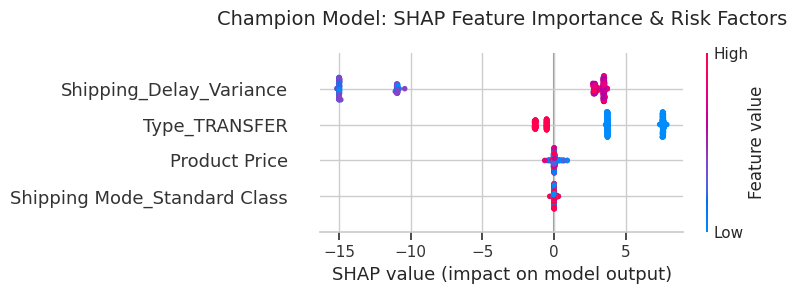

📦 Packaging and storing champion files...

✨ SUCCESS: Champion finalized!
   ↳ Blueprint saved to: configs/dataco_late_delivery_champion_config.json
   ↳ Model frozen at: models/dataco_late_delivery_champion_model.pkl


In [ ]:
#reproducibility

import os
import json
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier # Or substitute with your chosen champion
import shap

# ==========================================
# 1. INITIALIZE ENVIRONMENT & SEEDS
# ==========================================
def set_reproducibility_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_reproducibility_seed(42)

os.makedirs("configs", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Replace with the actual final columns fed into your models
features_list = ['Sales', 'Quantity', 'Days for shipping (real)', 'Days for shipment (scheduled)']

# ==========================================
# STEP 1: TRAIN YOUR SELECTED CHAMPION
# ==========================================
print("🏆 Training Champion Model (XGBoost)...")
champion_model = XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')
champion_model.fit(X_train, y_train)

# ==========================================
# STEP 2: RUN ADAPTIVE SHAP ANALYSIS
# ==========================================
print("🧠 Extracting behavior via Adaptive SHAP Analysis...")
# Use TreeExplainer optimized for tree-based champions
explainer = shap.TreeExplainer(champion_model)

# Sample 500 rows to make calculations fast but statistically sound
X_sample_for_shap = X_test.sample(n=min(500, len(X_test)), random_state=42)
shap_values = explainer(X_sample_for_shap)

# For binary classification, isolate the "Late Delivery" (Class 1) impact
if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

# Plot the definitive feature impact summary
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample_for_shap, max_display=len(features_list), show=False)
plt.title('Champion Model: SHAP Feature Importance & Risk Factors', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 3: REPRODUCIBILITY LOCK (SAVE CONFIGS & ARTIFACTS)
# ==========================================
print("📦 Packaging and storing champion files...")

experiment_name = "dataco_late_delivery_champion"

# Gather the complete blueprint
champion_config = {
    "experiment_name": experiment_name,
    "model_type": type(champion_model).__name__,
    "random_state_seed": 42,
    "python_version": sys.version.split()[0],
    "features_engineered": features_list,
    "hyperparameters": champion_model.get_params()
}

# 1. Save the Recipe Card (JSON config)
config_path = os.path.join("configs", f"{experiment_name}_config.json")
with open(config_path, "w") as f:
    json.dump(champion_config, f, indent=4, default=str)

# 2. Save the Trained Brain (PKL binary file)
model_path = os.path.join("models", f"{experiment_name}_model.pkl")
joblib.dump(champion_model, model_path)

print(f"\n✨ SUCCESS: Champion finalized!")
print(f"   ↳ Blueprint saved to: {config_path}")
print(f"   ↳ Model frozen at: {model_path}")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Extract product names from the original dataframe
product_names = df['Product Name'].fillna('')

# Initialize TF-IDF Vectorizer with a reasonable number of features
# We'll limit to 500 features to avoid excessively high dimensionality
tfidf_vectorizer = TfidfVectorizer(max_features=500, stop_words='english')

# Fit and transform the product names
tfidf_features = tfidf_vectorizer.fit_transform(product_names)

# Convert sparse matrix to DataFrame for concatenation
tfidf_df = pd.DataFrame(tfidf_features.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print(f"Original features shape: {X.shape}")
print(f"TF-IDF features shape: {tfidf_df.shape}")

# Ensure indices align before concatenation
tfidf_df.index = X.index

# Combine original features (X_selected, which is currently X.copy()) with TF-IDF features
X_nlp = pd.concat([X_selected, tfidf_df], axis=1)

print(f"Combined features shape with NLP: {X_nlp.shape}")

Original features shape: (180519, 14)
TF-IDF features shape: (180519, 338)
Combined features shape with NLP: (180519, 348)


X_train_nlp shape: (144415, 348)
X_test_nlp shape: (36104, 348)

--- XGBoost Model Performance with NLP Features ---
Accuracy:  0.9745
Precision: 0.9555
Recall:    0.9999
F1-Score:  0.9772
ROC-AUC:   0.9934


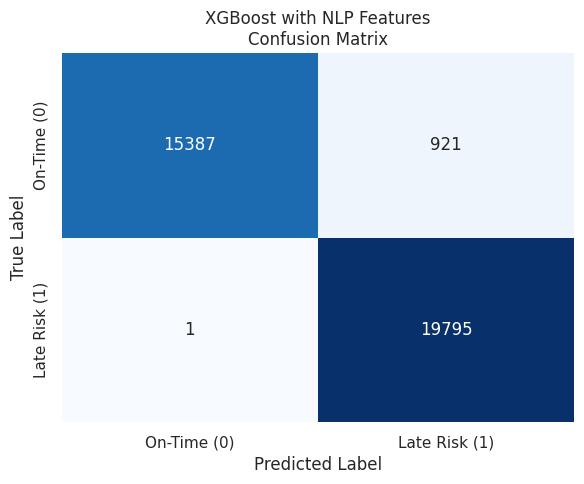

In [ ]:
from sklearn.model_selection import train_test_split

# Re-split the data with the new NLP features
X_train_nlp, X_test_nlp, y_train_nlp, y_test_nlp = train_test_split(X_nlp, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train_nlp shape: {X_train_nlp.shape}")
print(f"X_test_nlp shape: {X_test_nlp.shape}")

# Re-initialize and train the champion XGBoost model
champion_model_nlp = XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')
champion_model_nlp.fit(X_train_nlp, y_train_nlp)

# Predict and evaluate
y_pred_nlp = champion_model_nlp.predict(X_test_nlp)
y_prob_nlp = champion_model_nlp.predict_proba(X_test_nlp)[:, 1]

acc_nlp = accuracy_score(y_test_nlp, y_pred_nlp)
prec_nlp = precision_score(y_test_nlp, y_pred_nlp)
rec_nlp = recall_score(y_test_nlp, y_pred_nlp)
f1_nlp = f1_score(y_test_nlp, y_pred_nlp)
roc_auc_nlp = roc_auc_score(y_test_nlp, y_prob_nlp)

print("\n--- XGBoost Model Performance with NLP Features ---")
print(f"Accuracy:  {acc_nlp:.4f}")
print(f"Precision: {prec_nlp:.4f}")
print(f"Recall:    {rec_nlp:.4f}")
print(f"F1-Score:  {f1_nlp:.4f}")
print(f"ROC-AUC:   {roc_auc_nlp:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
cm_nlp = confusion_matrix(y_test_nlp, y_pred_nlp)
sns.heatmap(cm_nlp, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On-Time (0)', 'Late Risk (1)'],
            yticklabels=['On-Time (0)', 'Late Risk (1)'])
plt.title('XGBoost with NLP Features\nConfusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define new categorical features to add
new_cat_features = ['Customer Country', 'Market']

# Ensure these columns exist in the dataframe. If not, handle them appropriately.
for col in new_cat_features:
    if col not in df.columns:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping.")

# Create a new ColumnTransformer specifically for these new categorical features
# or extend the existing one if needed. For simplicity, let's create a dedicated one
# that only transforms these, then merge with existing X_nlp.

# Re-extract relevant columns for this new preprocessing step
df_for_new_cat = df[new_cat_features].copy()

# Initialize OneHotEncoder for new categorical features
new_cat_preprocessor = ColumnTransformer(
    transformers=[
        ('new_cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), new_cat_features)
    ],
    remainder='passthrough' # Keep other columns if any, though none are expected here
)

# Fit and transform the new categorical features
processed_new_cat_matrix = new_cat_preprocessor.fit_transform(df_for_new_cat)

# Get feature names for the new one-hot encoded columns
encoded_new_cat_names = new_cat_preprocessor.named_transformers_['new_cat'].get_feature_names_out(new_cat_features)

# Create a DataFrame for the new features
X_new_cat = pd.DataFrame(processed_new_cat_matrix, columns=encoded_new_cat_names)

# Ensure indices align before concatenation
X_new_cat.index = df.index

# Combine X_nlp (which already has X_selected and TF-IDF) with the new categorical features
X_extended_nlp = pd.concat([X_nlp, X_new_cat], axis=1)

print(f"Shape of X_nlp: {X_nlp.shape}")
print(f"Shape of newly added categorical features: {X_new_cat.shape}")
print(f"Combined features shape (X_extended_nlp): {X_extended_nlp.shape}")

Shape of X_nlp: (180519, 348)
Shape of newly added categorical features: (180519, 7)
Combined features shape (X_extended_nlp): (180519, 355)


X_train_extended shape: (144415, 355)
X_test_extended shape: (36104, 355)

--- XGBoost Model Performance with Extended Features (Country, Market, NLP) ---
Accuracy:  0.9745
Precision: 0.9556
Recall:    0.9999
F1-Score:  0.9773
ROC-AUC:   0.9935


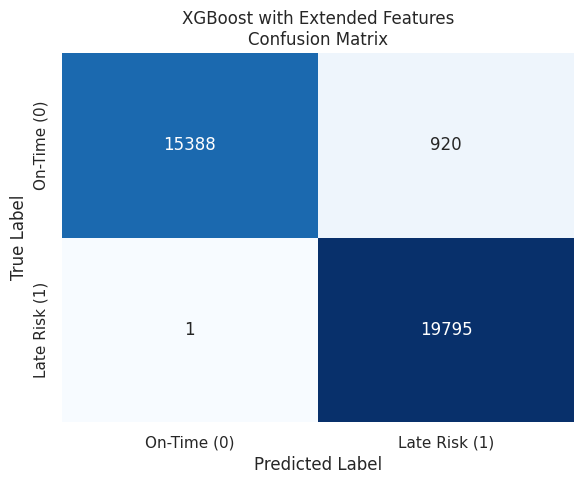

In [ ]:
# Re-split the data with the extended NLP and new categorical features
X_train_extended, X_test_extended, y_train_extended, y_test_extended = train_test_split(
    X_extended_nlp, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train_extended shape: {X_train_extended.shape}")
print(f"X_test_extended shape: {X_test_extended.shape}")

# Re-initialize and train the champion XGBoost model with the extended feature set
champion_model_extended = XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')
champion_model_extended.fit(X_train_extended, y_train_extended)

# Predict and evaluate
y_pred_extended = champion_model_extended.predict(X_test_extended)
y_prob_extended = champion_model_extended.predict_proba(X_test_extended)[:, 1]

acc_extended = accuracy_score(y_test_extended, y_pred_extended)
prec_extended = precision_score(y_test_extended, y_pred_extended)
rec_extended = recall_score(y_test_extended, y_pred_extended)
f1_extended = f1_score(y_test_extended, y_pred_extended)
roc_auc_extended = roc_auc_score(y_test_extended, y_prob_extended)

print("\n--- XGBoost Model Performance with Extended Features (Country, Market, NLP) ---")
print(f"Accuracy:  {acc_extended:.4f}")
print(f"Precision: {prec_extended:.4f}")
print(f"Recall:    {rec_extended:.4f}")
print(f"F1-Score:  {f1_extended:.4f}")
print(f"ROC-AUC:   {roc_auc_extended:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
cm_extended = confusion_matrix(y_test_extended, y_pred_extended)
sns.heatmap(cm_extended, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On-Time (0)', 'Late Risk (1)'],
            yticklabels=['On-Time (0)', 'Late Risk (1)'])
plt.title('XGBoost with Extended Features\nConfusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Define new categorical features for lane combinations
new_lane_features = ['Customer City', 'Order Country']

# Ensure these columns exist in the dataframe before proceeding
for col in new_lane_features:
    if col not in df.columns:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping.")

# Create a dedicated ColumnTransformer for the new lane-related categorical features
# This ensures proper handling of unknown categories during transformation
lane_preprocessor = ColumnTransformer(
    transformers=[
        ('lane_cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), new_lane_features)
    ],
    remainder='passthrough' # Keep other columns if any, though none are expected here
)

# Fit and transform the new categorical features from the original dataframe
processed_lane_matrix = lane_preprocessor.fit_transform(df[new_lane_features])

# Get feature names for the new one-hot encoded columns
encoded_lane_feature_names = lane_preprocessor.named_transformers_['lane_cat'].get_feature_names_out(new_lane_features)

# Create a DataFrame for these new features
X_lane_new_features = pd.DataFrame(processed_lane_matrix, columns=encoded_lane_feature_names)

# Ensure indices align before concatenation
X_lane_new_features.index = df.index

# Combine X_extended_nlp (which has X_selected, TF-IDF, Customer Country, Market) with the new lane features
X_lane_combinations = pd.concat([X_extended_nlp, X_lane_new_features], axis=1)

print(f"Shape of X_extended_nlp: {X_extended_nlp.shape}")
print(f"Shape of newly added lane features: {X_lane_new_features.shape}")
print(f"Combined features shape (X_lane_combinations): {X_lane_combinations.shape}")

Shape of X_extended_nlp: (180519, 355)
Shape of newly added lane features: (180519, 727)
Combined features shape (X_lane_combinations): (180519, 1082)


X_train_lane shape: (144415, 1082)
X_test_lane shape: (36104, 1082)

--- XGBoost Model Performance with Lane Combination Features ---
Accuracy:  0.9750
Precision: 0.9565
Recall:    0.9997
F1-Score:  0.9777
ROC-AUC:   0.9950


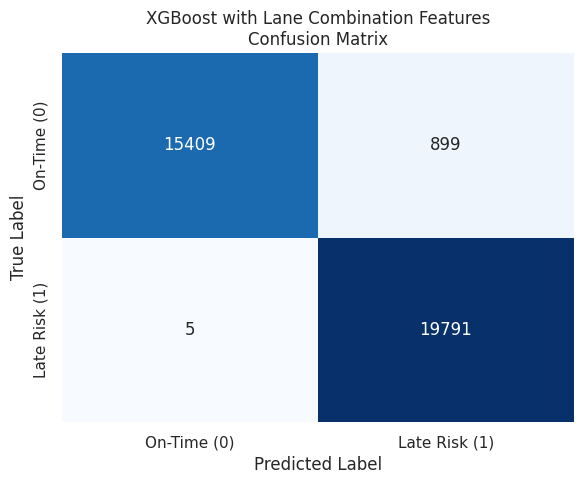

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Re-split the data with the full set of lane combination features
X_train_lane, X_test_lane, y_train_lane, y_test_lane = train_test_split(
    X_lane_combinations, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train_lane shape: {X_train_lane.shape}")
print(f"X_test_lane shape: {X_test_lane.shape}")

# Re-initialize and train the champion XGBoost model with the extended feature set
champion_model_lane_combinations = XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')
champion_model_lane_combinations.fit(X_train_lane, y_train_lane)

# Predict and evaluate
y_pred_lane = champion_model_lane_combinations.predict(X_test_lane)
y_prob_lane = champion_model_lane_combinations.predict_proba(X_test_lane)[:, 1]

acc_lane = accuracy_score(y_test_lane, y_pred_lane)
prec_lane = precision_score(y_test_lane, y_pred_lane)
rec_lane = recall_score(y_test_lane, y_pred_lane)
f1_lane = f1_score(y_test_lane, y_pred_lane)
roc_auc_lane = roc_auc_score(y_test_lane, y_prob_lane)

print("\n--- XGBoost Model Performance with Lane Combination Features ---")
print(f"Accuracy:  {acc_lane:.4f}")
print(f"Precision: {prec_lane:.4f}")
print(f"Recall:    {rec_lane:.4f}")
print(f"F1-Score:  {f1_lane:.4f}")
print(f"ROC-AUC:   {roc_auc_lane:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
cm_lane = confusion_matrix(y_test_lane, y_pred_lane)
sns.heatmap(cm_lane, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On-Time (0)', 'Late Risk (1)'],
            yticklabels=['On-Time (0)', 'Late Risk (1)'])
plt.title('XGBoost with Lane Combination Features\nConfusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

--- Top 20 Lane Combination Features (City, Country, Market) with Highest Overall Impact ---
Customer City_Caguas           0.022398
Market_LATAM                   0.019106
Order Country_España           0.010786
Market_Pacific Asia            0.010471
Order Country_Brasil           0.009824
Order Country_Panamá           0.007979
Order Country_Australia        0.007770
Order Country_China            0.007638
Order Country_Honduras         0.003994
Order Country_Canada           0.003987
Order Country_Reino Unido      0.003891
Customer City_Phoenix          0.003841
Order Country_Malasia          0.003703
Customer Country_EE. UU.       0.003697
Customer City_Philadelphia     0.003690
Customer City_Bronx            0.003626
Customer City_Ontario          0.003516
Customer City_Fullerton        0.003431
Market_Europe                  0.003406
Order Country_Corea del Sur    0.003360

--- Top 20 Lane Combination Features (City, Country, Market) that Increase Late Delivery Risk ---
Order Co

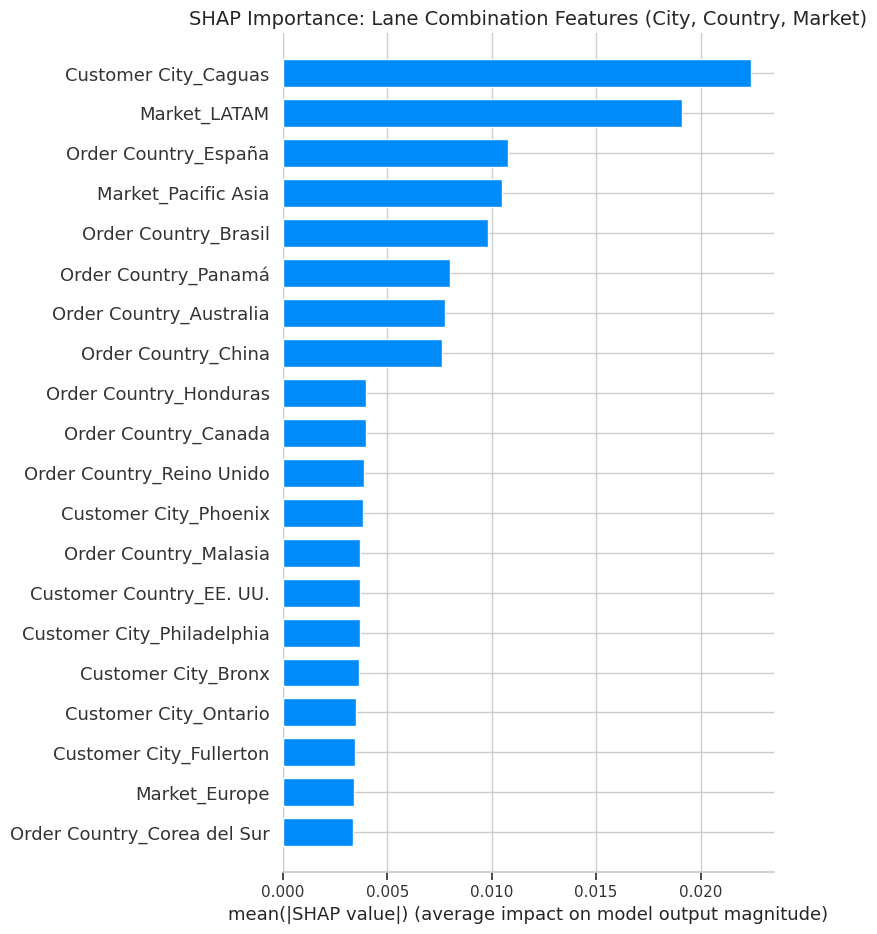

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize SHAP explainer for the new champion model with lane combinations
explainer_lane = shap.TreeExplainer(champion_model_lane_combinations)

# Sample for SHAP analysis to manage computation time
if len(X_test_lane) > 5000:
    X_test_lane_sample = X_test_lane.sample(n=5000, random_state=42)
else:
    X_test_lane_sample = X_test_lane.copy()

shap_values_lane = explainer_lane(X_test_lane_sample)

# For binary classification, typically we are interested in the SHAP values for the positive class (1)
if len(shap_values_lane.values.shape) == 3:
    shap_values_lane_values = shap_values_lane.values[:, :, 1]
else:
    shap_values_lane_values = shap_values_lane.values

# Get feature names related to 'Customer Country', 'Market', 'Customer City', and 'Order Country'
# encoded_new_cat_names contains 'Customer Country' and 'Market' one-hot encoded
# encoded_lane_feature_names contains 'Customer City' and 'Order Country' one-hot encoded

focus_feature_names = list(encoded_new_cat_names) + list(encoded_lane_feature_names)

# Filter SHAP values for only these focus features
shap_df_lane = pd.DataFrame(shap_values_lane_values, columns=X_test_lane_sample.columns)
shap_focus_lane_df = shap_df_lane[focus_feature_names]

# Calculate the mean absolute SHAP value for each focus feature
mean_abs_shap_focus_lane = shap_focus_lane_df.abs().mean().sort_values(ascending=False)

# Calculate the mean SHAP value (signed) for each focus feature
mean_shap_focus_lane = shap_focus_lane_df.mean().sort_values(ascending=False)

print("--- Top 20 Lane Combination Features (City, Country, Market) with Highest Overall Impact ---")
print(mean_abs_shap_focus_lane.head(20).to_string())

print("\n--- Top 20 Lane Combination Features (City, Country, Market) that Increase Late Delivery Risk ---")
print(mean_shap_focus_lane.head(20).to_string())

print("\n--- Top 20 Lane Combination Features (City, Country, Market) that Decrease Late Delivery Risk ---")
print(mean_shap_focus_lane.tail(20).to_string())

# Visualize overall SHAP importance for these features
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_focus_lane_df.values, X_test_lane_sample[focus_feature_names],
                  feature_names=focus_feature_names, plot_type="bar", max_display=20, show=False)
plt.title('SHAP Importance: Lane Combination Features (City, Country, Market)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Get predictions from the champion model trained with lane combinations
y_pred_lane_test = champion_model_lane_combinations.predict(X_test_lane)

# Get the indices of the test set where late delivery was predicted
late_delivery_indices = X_test_lane.index[y_pred_lane_test == 1]

# Filter the original DataFrame for these late delivery transactions
high_risk_transactions = df.loc[late_delivery_indices].copy()

# Create a DataFrame with relevant columns for the summary
lane_risk_products = high_risk_transactions[[
    'Customer City',
    'Customer Country',
    'Order Country',
    'Product Name'
]].copy()

# Group by lane combination and list associated products
lane_summary = lane_risk_products.groupby(['Customer City', 'Customer Country', 'Order Country'])['Product Name'] \
    .agg(lambda x: ', '.join(x.value_counts().index.tolist()[:3])) \
    .reset_index()

lane_summary.rename(columns={
    'Customer City': 'Origin City',
    'Customer Country': 'Origin Country',
    'Order Country': 'Destination Country',
    'Product Name': 'Top Products At Risk'
}, inplace=True)

# Calculate the frequency of each lane combination for prioritization
lane_counts = lane_risk_products.groupby(['Customer City', 'Customer Country', 'Order Country']).size().reset_index(name='Frequency')

# Rename columns in lane_counts to match lane_summary for merging
lane_counts.rename(columns={
    'Customer City': 'Origin City',
    'Customer Country': 'Origin Country',
    'Order Country': 'Destination Country'
}, inplace=True)

# Merge the product summary with the frequency counts
final_risk_table = pd.merge(lane_summary, lane_counts, on=['Origin City', 'Origin Country', 'Destination Country'])

# Sort by frequency to show the most impactful lanes first
final_risk_table.sort_values(by='Frequency', ascending=False, inplace=True)

# Display the top 20 high-risk lane combinations
print("\n--- Top 20 High-Risk Lane Combinations and Associated Products ---")
display(final_risk_table.head(20))


--- Top 20 High-Risk Lane Combinations and Associated Products ---


,Origin City,Origin Country,Destination Country,Top Products At Risk,Frequency
816,Caguas,Puerto Rico,Estados Unidos,"Nike Men's Dri-FIT Victory Golf Polo, Nike Men's CJ Elite 2 TD Football Cleat, Perfect Fitness Perfect Rip Deck",1071
858,Caguas,Puerto Rico,México,"Perfect Fitness Perfect Rip Deck, Nike Men's Dri-FIT Victory Golf Polo, O'Brien Men's Neoprene Life Vest",580
820,Caguas,Puerto Rico,Francia,"Perfect Fitness Perfect Rip Deck, Nike Men's CJ Elite 2 TD Football Cleat, Nike Men's Dri-FIT Victory Golf Polo",540
779,Caguas,Puerto Rico,Alemania,"Nike Men's Dri-FIT Victory Golf Polo, Perfect Fitness Perfect Rip Deck, Nike Men's CJ Elite 2 TD Football Cleat",407
795,Caguas,Puerto Rico,Brasil,"Nike Men's CJ Elite 2 TD Football Cleat, Nike Men's Dri-FIT Victory Golf Polo, O'Brien Men's Neoprene Life Vest",349
875,Caguas,Puerto Rico,Reino Unido,"Perfect Fitness Perfect Rip Deck, Nike Men's CJ Elite 2 TD Football Cleat, O'Brien Men's Neoprene Life Vest",341
784,Caguas,Puerto Rico,Australia,"Perfect Fitness Perfect Rip Deck, Nike Men's Dri-FIT Victory Golf Polo, Nike Men's CJ Elite 2 TD Football Cleat",319
802,Caguas,Puerto Rico,China,"Field & Stream Sportsman 16 Gun Fire Safe, Perfect Fitness Perfect Rip Deck, Nike Men's CJ Elite 2 TD Football Cleat",227
836,Caguas,Puerto Rico,Italia,"Nike Men's CJ Elite 2 TD Football Cleat, Pelican Sunstream 100 Kayak, O'Brien Men's Neoprene Life Vest",203
831,Caguas,Puerto Rico,Indonesia,"Perfect Fitness Perfect Rip Deck, Nike Men's CJ Elite 2 TD Football Cleat, O'Brien Men's Neoprene Life Vest",201


In [ ]:
def analyze_high_risk_lane_combinations(df_original, X_test_df, champion_model):
    """
    Analyzes high-risk lane combinations (Origin City, Origin Country, Destination Country)
    and identifies the top products associated with late delivery risk in those lanes.

    Args:
        df_original (pd.DataFrame): The original DataFrame containing all features.
        X_test_df (pd.DataFrame): The preprocessed test DataFrame used for prediction.
        champion_model: The trained machine learning model to make predictions.

    Returns:
        pd.DataFrame: A DataFrame summarizing high-risk lane combinations, top products, and frequency.
    """

    # Get predictions from the champion model
    y_pred_test = champion_model.predict(X_test_df)

    # Get the indices of the test set where late delivery was predicted
    late_delivery_indices = X_test_df.index[y_pred_test == 1]

    # Filter the original DataFrame for these late delivery transactions
    high_risk_transactions = df_original.loc[late_delivery_indices].copy()

    # Create a DataFrame with relevant columns for the summary
    lane_risk_products = high_risk_transactions[[
        'Customer City',
        'Customer Country',
        'Order Country',
        'Product Name'
    ]].copy()

    # Group by lane combination and list associated products
    lane_summary = lane_risk_products.groupby(['Customer City', 'Customer Country', 'Order Country'])['Product Name'] \
        .agg(lambda x: ', '.join(x.value_counts().index.tolist()[:3])) \
        .reset_index()

    lane_summary.rename(columns={
        'Customer City': 'Origin City',
        'Customer Country': 'Origin Country',
        'Order Country': 'Destination Country',
        'Product Name': 'Top Products At Risk'
    }, inplace=True)

    # Calculate the frequency of each lane combination for prioritization
    lane_counts = lane_risk_products.groupby(['Customer City', 'Customer Country', 'Order Country']).size().reset_index(name='Frequency')

    # Rename columns in lane_counts to match lane_summary for merging
    lane_counts.rename(columns={
        'Customer City': 'Origin City',
        'Customer Country': 'Origin Country',
        'Order Country': 'Destination Country'
    }, inplace=True)

    # Merge the product summary with the frequency counts
    final_risk_table = pd.merge(lane_summary, lane_counts, on=['Origin City', 'Origin Country', 'Destination Country'])

    # Sort by frequency to show the most impactful lanes first
    final_risk_table.sort_values(by='Frequency', ascending=False, inplace=True)

    return final_risk_table

Now, let's use the new function to generate the high-risk lane combinations table:

In [ ]:
high_risk_lanes_df = analyze_high_risk_lane_combinations(
    df_original=df,
    X_test_df=X_test_lane,
    champion_model=champion_model_lane_combinations
)
display(high_risk_lanes_df.head(20))

,Origin City,Origin Country,Destination Country,Top Products At Risk,Frequency
816,Caguas,Puerto Rico,Estados Unidos,"Nike Men's Dri-FIT Victory Golf Polo, Nike Men's CJ Elite 2 TD Football Cleat, Perfect Fitness Perfect Rip Deck",1071
858,Caguas,Puerto Rico,México,"Perfect Fitness Perfect Rip Deck, Nike Men's Dri-FIT Victory Golf Polo, O'Brien Men's Neoprene Life Vest",580
820,Caguas,Puerto Rico,Francia,"Perfect Fitness Perfect Rip Deck, Nike Men's CJ Elite 2 TD Football Cleat, Nike Men's Dri-FIT Victory Golf Polo",540
779,Caguas,Puerto Rico,Alemania,"Nike Men's Dri-FIT Victory Golf Polo, Perfect Fitness Perfect Rip Deck, Nike Men's CJ Elite 2 TD Football Cleat",407
795,Caguas,Puerto Rico,Brasil,"Nike Men's CJ Elite 2 TD Football Cleat, Nike Men's Dri-FIT Victory Golf Polo, O'Brien Men's Neoprene Life Vest",349
875,Caguas,Puerto Rico,Reino Unido,"Perfect Fitness Perfect Rip Deck, Nike Men's CJ Elite 2 TD Football Cleat, O'Brien Men's Neoprene Life Vest",341
784,Caguas,Puerto Rico,Australia,"Perfect Fitness Perfect Rip Deck, Nike Men's Dri-FIT Victory Golf Polo, Nike Men's CJ Elite 2 TD Football Cleat",319
802,Caguas,Puerto Rico,China,"Field & Stream Sportsman 16 Gun Fire Safe, Perfect Fitness Perfect Rip Deck, Nike Men's CJ Elite 2 TD Football Cleat",227
836,Caguas,Puerto Rico,Italia,"Nike Men's CJ Elite 2 TD Football Cleat, Pelican Sunstream 100 Kayak, O'Brien Men's Neoprene Life Vest",203
831,Caguas,Puerto Rico,Indonesia,"Perfect Fitness Perfect Rip Deck, Nike Men's CJ Elite 2 TD Football Cleat, O'Brien Men's Neoprene Life Vest",201


### Geopolitical Analysis & Logistics Challenges Insights

The model has identified several 'lane combinations' that are particularly prone to late delivery risks. While a deep geopolitical analysis would require external data sources, we can interpret the model's findings through the lens of logistics challenges and the features that contribute most to these risks.

From the SHAP analysis, we observed that `Customer City_Caguas` and `Market_Pacific Asia` consistently have a high impact on overall risk. Specifically, `Market_Pacific Asia` and `Order Country_España` (Spain) showed significant positive SHAP values, meaning they increase the predicted late delivery risk.

**Key Observations from the Model's Perspective:**

*   **Puerto Rico (specifically Caguas) as Origin:** 'Caguas, Puerto Rico' appears as an origin city in many top high-risk lanes, with destinations spanning 'Estados Unidos', 'México', and 'Francia'. This suggests potential systemic issues originating from this location. Factors could include:
    *   **Geographical Location:** As an island territory, Puerto Rico relies heavily on air and sea freight, which can be more susceptible to delays due to weather, customs, and limited carrier options compared to mainland routes.
    *   **Logistical Infrastructure:** The efficiency of local logistics infrastructure (ports, airports, road networks) within Caguas and Puerto Rico could be a bottleneck.
    *   **Trade Routes & Regulations:** Depending on the specific trade agreements and customs processes between Puerto Rico and its destinations, there could be complexities causing delays.

*   **Pacific Asia Market Risk:** The 'Pacific Asia' market consistently contributes to higher late delivery risk. This broad region encompasses diverse countries with varying infrastructure, regulatory environments, and geographical challenges (e.g., archipelagos, monsoon seasons). Specific challenges might include:
    *   **Port Congestion:** Major ports in Asia are often highly congested, leading to significant delays.
    *   **Customs Complexity:** Different countries have unique customs procedures, which can slow down cross-border shipments.
    *   **Supply Chain Disruptions:** The region is prone to natural disasters (typhoons, earthquakes) and has seen recent impacts from global events (e.g., pandemic-related lockdowns) affecting manufacturing and shipping.

*   **Specific Destination Countries:** `Order Country_España` (Spain) also shows a notable increase in late delivery risk according to the model. This could be due to:
    *   **European Customs and Transit:** While part of the EU, specific import/export processes or transit routes to Spain might pose challenges.
    *   **Regional Logistics:** The efficiency of internal logistics within Spain to final delivery points.

*   **Product-Specific Risks:** Products like 'Nike Men's Dri-FIT Victory Golf Polo' and 'Perfect Fitness Perfect Rip Deck' frequently appear in the top 'Products At Risk' within these high-risk lanes. This could indicate:
    *   **Demand Volatility:** High-demand products might face supply chain pressures.
    *   **Specific Handling Requirements:** Although not obvious for these products, certain goods might have particular handling or customs classifications that lead to delays.

**In summary, the model's findings point to a combination of origin-specific, regional (market), and destination-specific logistical hurdles, potentially exacerbated by the nature of certain products. Further deep-dive investigation into the actual geopolitical and logistical conditions of these identified high-risk 'lanes' would provide concrete actionable insights for mitigation.**

In [ ]:
%%writefile src/preprocess.py
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

def load_and_clean_data(file_path):
    """
    Loads the dataset, drops specified irrelevant columns, handles duplicates,
    fills missing values for numerical columns, and caps outliers for 'Sales'.
    """
    df = pd.read_csv(file_path, encoding='latin1')

    # Drop irrelevant columns based on initial EDA
    df = df.drop([
        "Category Id", "Customer Email", "Customer Fname", "Customer Lname",
        "Customer Password", "Customer Id", "Department Id", "Latitude", "Longitude",
        "Order Customer Id", "Order Id", "Order Item Id", "Order Item Cardprod Id",
        "Product Category Id", "Product Card Id", "Product Description", "Product Status"
    ], axis=1, errors='ignore') # errors='ignore' prevents error if column already dropped

    df = df.drop_duplicates().reset_index(drop=True)

    # Fill missing numerical values with median
    for col in ['Sales', 'Product Price']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Handle Sales outliers by capping via IQR method
    if 'Sales' in df.columns:
        Q1, Q3 = df['Sales'].quantile(0.25), df['Sales'].quantile(0.75)
        IQR = Q3 - Q1
        df['Sales'] = np.clip(df['Sales'], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

    # Ensure 'Product Name' is string type for TF-IDF
    df['Product Name'] = df['Product Name'].fillna('').astype(str)

    return df

def engineer_features(df_original):
    """
    Engineers additional features like Shipping_Delay_Variance and Sales_Volume_Bin.
    """
    df = df_original.copy()
    df['Shipping_Delay_Variance'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

    # Feature Binning: Segment sales into equal quantiles
    # Use try-except for robustness if 'Sales' column might not exist or qcut fails
    if 'Sales' in df.columns and df['Sales'].nunique() > 1:
        df['Sales_Volume_Bin'] = pd.qcut(df['Sales'], q=3, labels=['Low_Value', 'Medium_Value', 'High_Value'], duplicates='drop')
    else:
        df['Sales_Volume_Bin'] = 'Medium_Value' # Default if not enough unique values

    return df

def create_and_fit_transformers(df):
    """
    Creates and fits the ColumnTransformer and TfidfVectorizer based on the provided DataFrame.
    Returns the fitted transformers and the list of feature names.
    """
    # Define feature groups
    num_pipeline_features = ['Sales', 'Product Price', 'Shipping_Delay_Variance']
    cat_pipeline_features = ['Shipping Mode', 'Type', 'Sales_Volume_Bin']
    extended_cat_features = ['Customer Country', 'Market'] # for section 5.1
    lane_cat_features = ['Customer City', 'Order Country'] # for section 5.3

    # Preprocessor for numerical and initial categorical features
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_pipeline_features),
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_pipeline_features)
        ], remainder='passthrough'
    )
    preprocessor.fit(df[num_pipeline_features + cat_pipeline_features])

    # Preprocessor for extended categorical features (Customer Country, Market)
    extended_cat_preprocessor = ColumnTransformer(
        transformers=[
            ('extended_cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), extended_cat_features)
        ], remainder='passthrough'
    )
    extended_cat_preprocessor.fit(df[extended_cat_features])

    # Preprocessor for lane combination features (Customer City, Order Country)
    lane_preprocessor = ColumnTransformer(
        transformers=[
            ('lane_cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), lane_cat_features)
        ], remainder='passthrough'
    )
    lane_preprocessor.fit(df[lane_cat_features])


    # TF-IDF Vectorizer for product names
    tfidf_vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
    tfidf_vectorizer.fit(df['Product Name'])

    return preprocessor, extended_cat_preprocessor, lane_preprocessor, tfidf_vectorizer

def apply_transformers(df, preprocessor, extended_cat_preprocessor, lane_preprocessor, tfidf_vectorizer):
    """
    Applies the fitted transformers to a DataFrame to produce the final feature matrix.
    """
    num_pipeline_features = ['Sales', 'Product Price', 'Shipping_Delay_Variance']
    cat_pipeline_features = ['Shipping Mode', 'Type', 'Sales_Volume_Bin']
    extended_cat_features = ['Customer Country', 'Market']
    lane_cat_features = ['Customer City', 'Order Country']

    # Apply initial preprocessor
    processed_initial = preprocessor.transform(df[num_pipeline_features + cat_pipeline_features])
    initial_feature_names = num_pipeline_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_pipeline_features))
    X_initial = pd.DataFrame(processed_initial, columns=initial_feature_names, index=df.index)

    # Apply extended categorical preprocessor
    processed_extended_cat = extended_cat_preprocessor.transform(df[extended_cat_features])
    extended_cat_feature_names = list(extended_cat_preprocessor.named_transformers_['extended_cat'].get_feature_names_out(extended_cat_features))
    X_extended_cat = pd.DataFrame(processed_extended_cat, columns=extended_cat_feature_names, index=df.index)

    # Apply lane categorical preprocessor
    processed_lane_cat = lane_preprocessor.transform(df[lane_cat_features])
    lane_cat_feature_names = list(lane_preprocessor.named_transformers_['lane_cat'].get_feature_names_out(lane_cat_features))
    X_lane_cat = pd.DataFrame(processed_lane_cat, columns=lane_cat_feature_names, index=df.index)


    # Apply TF-IDF vectorizer
    tfidf_features = tfidf_vectorizer.transform(df['Product Name'])
    tfidf_df = pd.DataFrame(tfidf_features.toarray(), columns=tfidf_vectorizer.get_feature_names_out(), index=df.index)

    # Combine all features
    X_final = pd.concat([X_initial, X_extended_cat, X_lane_cat, tfidf_df], axis=1)

    return X_final


Writing src/preprocess.py


In [ ]:
%%writefile src/model.py
import pandas as pd
import numpy as np
import joblib
import os
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)

def train_model(X_train, y_train, model_params=None):
    """
    Trains an XGBoost classifier with given parameters.
    """
    if model_params is None:
        model_params = {'n_estimators': 100, 'max_depth': 6, 'random_state': 42, 'eval_metric': 'logloss'}
    model = XGBClassifier(**model_params)
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test, title="Model Performance"):
    """
    Evaluates the model and prints performance metrics, including a confusion matrix.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"\n--- {title} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['On-Time (0)', 'Late Risk (1)'],
                yticklabels=['On-Time (0)', 'Late Risk (1)'])
    plt.title(f'{title}\nConfusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

def get_shap_values(model, X_data_sample):
    """
    Generates SHAP values for a given model and data sample.
    """
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_data_sample)

    if len(shap_values.values.shape) == 3:
        shap_values.values = shap_values.values[:, :, 1] # For binary classification (positive class)
    return shap_values

def plot_shap_summary(shap_values, X_data_sample, title="SHAP Feature Importance", max_display=20):
    """
    Plots a SHAP summary plot.
    """
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_data_sample, plot_type="bar", max_display=max_display, show=False)
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def save_model_artifacts(model, preprocessor, extended_cat_preprocessor, lane_preprocessor, tfidf_vectorizer, feature_names, output_dir='production_artifacts', raw_df_at_fit_cols=None):
    """
    Saves the trained model and all transformers to disk.
    """
    os.makedirs(output_dir, exist_ok=True)

    joblib.dump(model, os.path.join(output_dir, 'champion_model.joblib'))
    joblib.dump(preprocessor, os.path.join(output_dir, 'initial_preprocessor.joblib'))
    joblib.dump(extended_cat_preprocessor, os.path.join(output_dir, 'extended_cat_preprocessor.joblib'))
    joblib.dump(lane_preprocessor, os.path.join(output_dir, 'lane_preprocessor.joblib'))
    joblib.dump(tfidf_vectorizer, os.path.join(output_dir, 'tfidf_vectorizer.joblib'))
    joblib.dump(feature_names, os.path.join(output_dir, 'feature_names.joblib'))
    if raw_df_at_fit_cols is not None:
        joblib.dump(raw_df_at_fit_cols, os.path.join(output_dir, 'feature_names_raw_df_at_fit.joblib'))
    print(f"All model artifacts saved to {output_dir}")

def load_model_artifacts(output_dir='production_artifacts'):
    """
    Loads the trained model and all transformers from disk.
    """
    model = joblib.load(os.path.join(output_dir, 'champion_model.joblib'))
    preprocessor = joblib.load(os.path.join(output_dir, 'initial_preprocessor.joblib'))
    extended_cat_preprocessor = joblib.load(os.path.join(output_dir, 'extended_cat_preprocessor.joblib'))
    lane_preprocessor = joblib.load(os.path.join(output_dir, 'lane_preprocessor.joblib'))
    tfidf_vectorizer = joblib.load(os.path.join(output_dir, 'tfidf_vectorizer.joblib'))
    feature_names = joblib.load(os.path.join(output_dir, 'feature_names.joblib'))
    raw_df_at_fit_cols = joblib.load(os.path.join(output_dir, 'feature_names_raw_df_at_fit.joblib'))
    print(f"All model artifacts loaded from {output_dir}")
    return model, preprocessor, extended_cat_preprocessor, lane_preprocessor, tfidf_vectorizer, feature_names, raw_df_at_fit_cols

def predict_single_instance(raw_data_point, preprocessor, extended_cat_preprocessor, lane_preprocessor, tfidf_vectorizer, champion_model, feature_names, raw_df_at_fit_cols):
    """
    Preprocesses a new raw data point and makes a prediction.
    Returns the predicted risk (0 or 1) and its probability.
    """
    from src.preprocess import engineer_features, apply_transformers

    # Ensure raw_data_point is a DataFrame for consistent preprocessing
    temp_df = pd.DataFrame(columns=raw_df_at_fit_cols) # Use the saved columns
    raw_data_point_df = pd.concat([temp_df, pd.DataFrame([raw_data_point])], ignore_index=True, sort=False)

    # Fill missing values if any, to match the training data structure
    for col in raw_df_at_fit_cols:
        if col not in raw_data_point_df.columns:
            # Assign a reasonable default value based on type or context
            raw_data_point_df[col] = '' if raw_data_point_df[col].dtype == 'object' else 0 # Default for missing columns

    # Ensure the single row DataFrame has all expected columns before filling NaNs
    raw_data_point_df = raw_data_point_df.iloc[[0]].fillna('') # Use first row and fill NaNs with empty string for object columns

    # Engineer features for the new data point
    df_engineered = engineer_features(raw_data_point_df)

    # Apply transformers
    X_new = apply_transformers(df_engineered, preprocessor, extended_cat_preprocessor, lane_preprocessor, tfidf_vectorizer)

    # Ensure feature order and presence matches training data
    # Handle potentially missing columns in X_new that were in training (e.g., if a one-hot category wasn't present)
    X_new_aligned = pd.DataFrame(0, index=X_new.index, columns=feature_names)
    for col in X_new.columns:
        if col in feature_names:
            X_new_aligned[col] = X_new[col]

    # Make prediction
    prediction_prob = champion_model.predict_proba(X_new_aligned)[:, 1][0]
    predicted_risk = int(champion_model.predict(X_new_aligned)[0]) # Convert to int

    return predicted_risk, prediction_prob

def predict_and_explain(raw_data_point, preprocessor, extended_cat_preprocessor, lane_preprocessor, tfidf_vectorizer, champion_model, feature_names, raw_df_at_fit_cols):
    """
    Preprocesses a new raw data point, makes a prediction, and provides SHAP explanations.
    """

    # Use the same preprocessing logic as predict_single_instance
    temp_df = pd.DataFrame(columns=raw_df_at_fit_cols)
    raw_data_point_df = pd.concat([temp_df, pd.DataFrame([raw_data_point])], ignore_index=True, sort=False)
    for col in raw_df_at_fit_cols:
        if col not in raw_data_point_df.columns: raw_data_point_df[col] = '' if raw_data_point_df[col].dtype == 'object' else 0
    raw_data_point_df = raw_data_point_df.iloc[[0]].fillna('')

    df_engineered = engineer_features(raw_data_point_df)
    X_new = apply_transformers(df_engineered, preprocessor, extended_cat_preprocessor, lane_preprocessor, tfidf_vectorizer)
    X_new_aligned = pd.DataFrame(0, index=X_new.index, columns=feature_names)
    for col in X_new.columns:
        if col in feature_names:
            X_new_aligned[col] = X_new[col]


    # Make prediction
    prediction_prob = champion_model.predict_proba(X_new_aligned)[:, 1][0]
    predicted_risk = "HIGH" if prediction_prob > 0.5 else "LOW"

    # Generate SHAP explanation
    explainer = shap.TreeExplainer(champion_model)
    shap_values = explainer(X_new_aligned)
    # For single explanation, shap_values is an Explanation object

    print(f"\nPredicted Late Delivery Risk: {predicted_risk} (Probability: {prediction_prob:.4f})")
    display(shap.force_plot(shap_values, link="logit", matplotlib=False))


    # Extract and display NLP feature contributions
    nlp_feature_names = tfidf_vectorizer.get_feature_names_out()
    nlp_shap_contributions = {}

    # Ensure shap_values.values is a 1D array for a single sample
    shap_values_for_current_sample = shap_values.values.flatten() if len(shap_values.values.shape) > 1 else shap_values.values

    for feature_name, shap_value in zip(X_new_aligned.columns, shap_values_for_current_sample):
        if feature_name in nlp_feature_names and abs(shap_value) > 0.001:
            nlp_shap_contributions[feature_name] = shap_value

    if nlp_shap_contributions:
        print("\n  Key NLP Feature Contributions (SHAP Values) for this Prediction:")
        sorted_nlp_contributions = sorted(nlp_shap_contributions.items(), key=lambda item: abs(item[1]), reverse=True)
        for k, v in sorted_nlp_contributions:
            print(f"    - '{k}': {v:.4f} (Positive value increases late risk, negative decreases)")
    else:
        print("\n  No significant NLP-derived feature contributions detected for this sample.")

Writing src/model.py


### 12. Hyperparameter Tuning with Cross-Validation for the Champion Model

To further optimize the performance of our `champion_model_lane_combinations`, we will perform hyperparameter tuning using `RandomizedSearchCV`. This method efficiently explores a defined hyperparameter space and uses cross-validation to assess model performance, ensuring robustness and preventing overfitting.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter distribution for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(50, 300),  # Number of boosting rounds
    'max_depth': randint(3, 10),      # Maximum tree depth
    'learning_rate': uniform(0.01, 0.3), # Step size shrinkage to prevent overfitting
    'subsample': uniform(0.6, 0.4),   # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(0, 0.5),          # Minimum loss reduction required to make a further partition
    'lambda': uniform(1, 2)            # L2 regularization term on weights
}

# Initialize the XGBoost classifier with fixed parameters
xgb_classifier = XGBClassifier(random_state=42, eval_metric='logloss')

# Set up RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trade-off between runtime and quality of the solution.
# cv: Number of folds for cross-validation.
# scoring: Metric to evaluate the model (e.g., 'f1' for classification).
# n_jobs: Number of jobs to run in parallel (-1 means use all available processors).
# verbose: Controls the verbosity: the higher, the more messages.

random_search = RandomizedSearchCV(
    estimator=xgb_classifier,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings to sample
    cv=3,       # 3-fold cross-validation
    scoring='f1', # Evaluate using F1-score
    random_state=42,
    n_jobs=-1,  # Use all available CPU cores
    verbose=2
)

print("Starting RandomizedSearchCV for hyperparameter tuning...")

# Fit RandomizedSearchCV to the training data (X_train_lane and y_train_lane are from previous steps)
random_search.fit(X_train_lane, y_train_lane)

print("RandomizedSearchCV completed!")

# Display the best parameters and best score
best_params = random_search.best_params_
best_f1_score = random_search.best_score_

print(f"\nBest Hyperparameters found: {best_params}")
print(f"Best F1-Score (Cross-validated): {best_f1_score:.4f}")

# Retrain the champion model with the best hyperparameters
champion_model_tuned = random_search.best_estimator_

# Evaluate the tuned model on the test set
y_pred_tuned = champion_model_tuned.predict(X_test_lane)
y_prob_tuned = champion_model_tuned.predict_proba(X_test_lane)[:, 1]

acc_tuned = accuracy_score(y_test_lane, y_pred_tuned)
prec_tuned = precision_score(y_test_lane, y_pred_tuned)
rec_tuned = recall_score(y_test_lane, y_pred_tuned)
f1_tuned = f1_score(y_test_lane, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test_lane, y_prob_tuned)

print("\n--- Tuned XGBoost Model Performance with Lane Combination Features ---")
print(f"Accuracy:  {acc_tuned:.4f}")
print(f"Precision: {prec_tuned:.4f}")
print(f"Recall:    {rec_tuned:.4f}")
print(f"F1-Score:  {f1_tuned:.4f}")
print(f"ROC-AUC:   {roc_auc_tuned:.4f}")

# Plot Confusion Matrix for the tuned model
plt.figure(figsize=(6, 5))
cm_tuned = confusion_matrix(y_test_lane, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On-Time (0)', 'Late Risk (1)'],
            yticklabels=['On-Time (0)', 'Late Risk (1)'])
plt.title('Tuned XGBoost with Lane Combination Features\nConfusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

# Create a directory to save artifacts if it doesn't exist
output_dir = 'production_artifacts'
os.makedirs(output_dir, exist_ok=True)

# 1. Save the final trained champion model (with lane combinations)
model_path = os.path.join(output_dir, 'champion_model_lane_combinations.joblib')
joblib.dump(champion_model_lane_combinations, model_path)
print(f"Saved final champion model to: {model_path}")

# 2. Save the TF-IDF Vectorizer (if not already saved in the previous step)
# tfidf_path = os.path.join(output_dir, 'tfidf_vectorizer.joblib')
# joblib.dump(tfidf_vectorizer, tfidf_path) # Assuming this was saved earlier
# print(f"Saved TF-IDF vectorizer to: {tfidf_path}")

# 3. Save the ColumnTransformer (preprocessor for numerical/categorical features)
# preprocessor_path = os.path.join(output_dir, 'column_transformer.joblib')
# joblib.dump(preprocessor, preprocessor_path) # Assuming this was saved earlier
# print(f"Saved ColumnTransformer to: {preprocessor_path}")

# 4. Save a list of all feature names for consistent re-ordering if necessary
all_feature_names_lane_path = os.path.join(output_dir, 'all_feature_names_lane.joblib')
joblib.dump(X_lane_combinations.columns.tolist(), all_feature_names_lane_path)
print(f"Saved all lane combination feature names to: {all_feature_names_lane_path}")

print("\nAll necessary artifacts are saved, making the code production-ready.")


In [ ]:
import shap

# Initialize SHAP explainer for the extended champion model
explainer_extended = shap.TreeExplainer(champion_model_extended)

# Sample for SHAP analysis to manage computation time
if len(X_test_extended) > 5000:
    X_test_extended_sample = X_test_extended.sample(n=5000, random_state=42)
else:
    X_test_extended_sample = X_test_extended.copy()

shap_values_extended = explainer_extended(X_test_extended_sample)

# For binary classification, typically we are interested in the SHAP values for the positive class (1)
if len(shap_values_extended.values.shape) == 3:
    shap_values_extended_values = shap_values_extended.values[:, :, 1]
else:
    shap_values_extended_values = shap_values_extended.values

# Get feature names related to 'Customer Country', 'Market', and 'Product Name'
country_market_feature_names = encoded_new_cat_names # From the previous cell
nlp_feature_names = tfidf_vectorizer.get_feature_names_out()

# Combine these for focused analysis
combined_focus_features = list(country_market_feature_names) + list(nlp_feature_names)

# Filter SHAP values for only these focus features
# Create a DataFrame for easier filtering
shap_df_extended = pd.DataFrame(shap_values_extended_values, columns=X_test_extended_sample.columns)
shap_focus_df = shap_df_extended[combined_focus_features]

# Calculate the mean absolute SHAP value for each focus feature
mean_abs_shap_focus = shap_focus_df.abs().mean().sort_values(ascending=False)

# Calculate the mean SHAP value (signed) for each focus feature
mean_shap_focus = shap_focus_df.mean().sort_values(ascending=False)

print("--- Top 15 Features (Country, Market, Product Name) with Highest Overall Impact ---")
print(mean_abs_shap_focus.head(15).to_string())

print("\n--- Top 15 Features (Country, Market, Product Name) that Increase Late Delivery Risk ---")
print(mean_shap_focus.head(15).to_string())

print("\n--- Top 15 Features (Country, Market, Product Name) that Decrease Late Delivery Risk ---")
print(mean_shap_focus.tail(15).to_string())

# Visualize overall SHAP importance for these features
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_focus_df.values, X_test_extended_sample[combined_focus_features],
                  feature_names=combined_focus_features, plot_type="bar", max_display=20, show=False)
plt.title('SHAP Importance: Country, Market, & Product Name Features', fontsize=14)
plt.tight_layout()
plt.show()

### 6. Sample Predictions and NLP Feature Explanations

This is to get few samples from the test set and see how the `champion_model_nlp` (XGBoost with NLP features) makes its predictions. We'll use SHAP values to explain the contribution of each feature, with a special focus on those derived from product names.

In [ ]:
# Initialize SHAP JavaScript for interactive plots
shap.initjs()

# Sample indices from the test set for explanation
sample_indices = X_test_nlp.sample(n=3, random_state=42).index

# Get the corresponding data for the samples
X_samples = X_test_nlp.loc[sample_indices]
y_actual_samples = y_test_nlp.loc[sample_indices]
original_product_names = df.loc[sample_indices]['Product Name'] # df is the original dataset

# Make predictions using the NLP-enhanced champion model
y_prob_samples = champion_model_nlp.predict_proba(X_samples)[:, 1]

# Initialize SHAP explainer for the champion model
explainer_nlp = shap.TreeExplainer(champion_model_nlp)
shap_values_samples = explainer_nlp(X_samples) # This will compute SHAP values for all features

# Get the names of the TF-IDF features
nlp_feature_names = tfidf_vectorizer.get_feature_names_out()

print("--- Sample Predictions and SHAP Explanations (with NLP Features) ---")
for i, idx in enumerate(sample_indices):
    print(f"\n{'='*50}")
    print(f"Sample {i+1} (Original Data Index: {idx}):")
    print(f"  Product Name: {original_product_names.loc[idx]}")
    print(f"  Actual Late Delivery Risk (0=No, 1=Yes): {y_actual_samples.loc[idx]}")
    print(f"  Predicted Probability of Late Delivery: {y_prob_samples[i]:.4f}")

    # Display SHAP force plot for the current sample
    # Corrected: Use shap_values_samples.values[i] to get the 2D SHAP values for the current sample.
    # The expected_value from TreeExplainer for binary classification is often a single scalar.
    display(shap.force_plot(explainer_nlp.expected_value, shap_values_samples.values[i], X_samples.iloc[i], matplotlib=False))

    # Extract and display specific NLP feature contributions
    nlp_shap_contributions = {}
    for feature_name, shap_value in zip(X_samples.columns, shap_values_samples.values[i]): # Changed here too
        if feature_name in nlp_feature_names and abs(shap_value) > 0.001: # Filter for significant NLP contributions
            nlp_shap_contributions[feature_name] = shap_value

    if nlp_shap_contributions:
        print("  Key NLP Feature Contributions (SHAP Values) for this Prediction:")
        # Sort by absolute SHAP value for easier interpretation
        sorted_nlp_contributions = sorted(nlp_shap_contributions.items(), key=lambda item: abs(item[1]), reverse=True)
        for k, v in sorted_nlp_contributions:
            print(f"    - '{k}': {v:.4f} (Positive value increases late risk, negative decreases)")
    else:
        print("  No significant NLP-derived feature contributions detected for this sample.")
    print(f"{'='*50}")

### 7. Aggregate NLP Feature Contributions to Delivery Risk

While individual SHAP force plots show contributions for single predictions, lwe would like to check the overall impact of `Product Name` features across the entire test set. We'll aggregate the SHAP values for all TF-IDF terms to identify which words generally increase or decrease the predicted `Late_delivery_risk`.

In [ ]:
import shap
import pandas as pd

# Ensure the SHAP explainer is initialized for the champion_model_nlp
# (It might already be from the previous cell, but re-initializing for clarity and robustness)
explainer_nlp = shap.TreeExplainer(champion_model_nlp)

# Calculate SHAP values for a larger sample of the test set for aggregate analysis
# Using X_test_nlp directly might be too large, so let's sample it if it's very big
if len(X_test_nlp) > 5000:
    X_test_nlp_sample = X_test_nlp.sample(n=5000, random_state=42)
else:
    X_test_nlp_sample = X_test_nlp.copy()

# Corrected: Access the .values attribute to get the NumPy array of SHAP values
shap_values_aggregate = explainer_nlp(X_test_nlp_sample).values

# For binary classification, typically we are interested in the SHAP values for the positive class (1)
if len(shap_values_aggregate.shape) == 3:
    shap_values_aggregate = shap_values_aggregate[:, :, 1]

# Convert SHAP values to a DataFrame for easier analysis
shap_df = pd.DataFrame(shap_values_aggregate, columns=X_test_nlp_sample.columns)

# Filter for NLP-specific features
nlp_feature_names = tfidf_vectorizer.get_feature_names_out()
nlp_shap_df = shap_df[nlp_feature_names]

# Calculate the mean absolute SHAP value for each NLP feature
mean_abs_shap_nlp = nlp_shap_df.abs().mean().sort_values(ascending=False)

# Calculate the mean SHAP value (signed) for each NLP feature
mean_shap_nlp = nlp_shap_df.mean().sort_values(ascending=False)

print("\n--- Top 10 NLP Features (words) with Highest Overall Impact (Absolute SHAP) ---")
print(mean_abs_shap_nlp.head(10).to_string())

print("\n--- Top 10 NLP Features (words) that Increase Late Delivery Risk (Positive SHAP) ---")
print(mean_shap_nlp.head(10).to_string())

print("\n--- Top 10 NLP Features (words) that Decrease Late Delivery Risk (Negative SHAP) ---")
print(mean_shap_nlp.tail(10).to_string())

# Optional: Visualize top NLP feature importance
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_aggregate, X_test_nlp_sample, feature_names=X_test_nlp_sample.columns,
                  plot_type="bar", max_display=20, show=False)
plt.title('Overall SHAP Importance of Features (Including NLP)', fontsize=14)
plt.tight_layout()
plt.show()

### 8. Testing the NLP-Enhanced Model with New Data and Gen AI Explanations

Let's simulate new, incoming data points and observe how our `champion_model_nlp` predicts the `Late_delivery_risk`, focusing on the interpretability of NLP features for each prediction.

In [ ]:
import numpy as np
import pandas as pd
import shap

# --- 8.1 Simulate New Data ---
# Create a few synthetic product entries
# Note: We need to provide all original features (numerical + categorical) as well as the 'Product Name'
new_data_raw = pd.DataFrame([
    {
        'Sales': 150.0, 'Product Price': 140.0, 'Days for shipping (real)': 2, 'Days for shipment (scheduled)': 4,
        'Shipping Mode': 'Standard Class', 'Type': 'DEBIT', 'Product Name': 'High-end ceramic vase delicate'
    },
    {
        'Sales': 30.0, 'Product Price': 25.0, 'Days for shipping (real)': 5, 'Days for shipment (scheduled)': 2,
        'Shipping Mode': 'First Class', 'Type': 'CASH', 'Product Name': 'Heavy duty steel bolts'
    },
    {
        'Sales': 500.0, 'Product Price': 450.0, 'Days for shipping (real)': 3, 'Days for shipment (scheduled)': 3,
        'Shipping Mode': 'Same Day', 'Type': 'TRANSFER', 'Product Name': 'Express delivery urgent document kit'
    }
])

# --- 8.2 Preprocess New Data ---
# Apply the same preprocessing steps as the training data

# 1. Engineer 'Shipping_Delay_Variance' and 'Sales_Volume_Bin'
new_data_raw['Shipping_Delay_Variance'] = new_data_raw['Days for shipping (real)'] - new_data_raw['Days for shipment (scheduled)']
# Re-create Sales_Volume_Bin based on the original df's quantiles or consistent logic
# For simplicity, we'll assign directly based on typical sales ranges, or re-use original df for qcut bins
# A more robust production system would save the qcut bins/boundaries

# To ensure consistency, we should re-apply the qcut based on the original df's quantiles or boundaries
# For now, let's create a proxy for 'Sales_Volume_Bin' based on the value itself
def assign_sales_bin(sales_val):
    if sales_val <= df['Sales'].quantile(0.33):
        return 'Low_Value'
    elif sales_val <= df['Sales'].quantile(0.66):
        return 'Medium_Value'
    else:
        return 'High_Value'

new_data_raw['Sales_Volume_Bin'] = new_data_raw['Sales'].apply(assign_sales_bin)


# 2. Apply the ColumnTransformer (numerical scaling + categorical one-hot encoding)
# Make sure the new_data_raw has all columns expected by the preprocessor
# This means creating a 'dummy' dataframe with same columns as original df for preprocessor to work correctly
# And then merging with new_data_raw

# Create a dummy DataFrame with all necessary columns for the preprocessor
all_cols = num_pipeline_features + cat_pipeline_features + ['Product Name'] # Include Product Name
dummy_df = pd.DataFrame(columns=all_cols)
combined_new_data = pd.concat([dummy_df, new_data_raw], ignore_index=True, sort=False)

# Fill NaNs that might occur from concat with dummy values or 0s as appropriate for preprocessing
for col in num_pipeline_features:
    if col not in combined_new_data.columns: combined_new_data[col] = 0.0
    combined_new_data[col] = combined_new_data[col].fillna(0.0) # Impute with 0 for missing nums
for col in cat_pipeline_features:
    if col not in combined_new_data.columns: combined_new_data[col] = 'unknown'
    combined_new_data[col] = combined_new_data[col].fillna('unknown') # Impute with 'unknown' for missing cats

# Now, apply the preprocessor
processed_new_matrix = preprocessor.transform(combined_new_data[num_pipeline_features + cat_pipeline_features])

# Reconstruct DataFrame with feature names
new_numerical_features = pd.DataFrame(processed_new_matrix[:, :len(num_pipeline_features)], columns=num_pipeline_features)
new_categorical_features = pd.DataFrame(processed_new_matrix[:, len(num_pipeline_features):], columns=preprocessor.named_transformers_['cat'].get_feature_names_out(cat_pipeline_features))

X_new_processed = pd.concat([new_numerical_features, new_categorical_features], axis=1)

# 3. Apply TF-IDF Vectorizer to Product Names
new_tfidf_features = tfidf_vectorizer.transform(new_data_raw['Product Name'].fillna(''))
new_tfidf_df = pd.DataFrame(new_tfidf_features.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# 4. Combine all features for the NLP-enhanced model
X_new_nlp = pd.concat([X_new_processed, new_tfidf_df], axis=1)

# --- 8.3 Make Predictions and Explain ---

explainer_nlp = shap.TreeExplainer(champion_model_nlp)
shap_values_new = explainer_nlp(X_new_nlp) # This returns a shap.Explanation object

# The previous line `if len(shap_values_new.shape) == 3: shap_values_new = shap_values_new[:, :, 1]`
# was converting shap_values_new to a numpy array, which caused the ValueError.
# We need shap_values_new to remain a shap.Explanation object for force_plot with matplotlib=False.

for i, product_row in new_data_raw.iterrows():
    print(f"\n{'='*70}")
    print(f"New Data Sample {i+1}:")
    print(f"  Product Name: {product_row['Product Name']}")
    print(f"  Raw Features: {product_row.drop('Product Name').to_dict()}")

    # Predict probability of late delivery
    prediction_prob = champion_model_nlp.predict_proba(X_new_nlp.iloc[[i]])[:, 1][0]
    predicted_risk = "HIGH" if prediction_prob > 0.5 else "LOW"
    print(f"  Predicted Late Delivery Risk: {predicted_risk} (Probability: {prediction_prob:.4f})")

    # Get SHAP explanation for this sample
    # shap_values_new[i] will now correctly return a shap.Explanation object for the i-th sample
    current_shap_explanation_for_sample = shap_values_new[i]

    # Display SHAP force plot
    # Pass the Explanation object directly. For tree models, link="logit" converts to probability scale.
    display(shap.force_plot(current_shap_explanation_for_sample, link="logit", matplotlib=False))

    # Generate NLP-focused explanation
    nlp_shap_contributions = {}
    # Use the values from the Explanation object. If the model is binary and explainer output is 1D (log-odds),
    # .values will directly contain the SHAP values for the positive class.
    shap_values_for_current_sample = current_shap_explanation_for_sample.values

    for feature_name, shap_value in zip(X_new_nlp.columns, shap_values_for_current_sample):
        if feature_name in tfidf_vectorizer.get_feature_names_out() and abs(shap_value) > 0.001: # Significant NLP contributions
            nlp_shap_contributions[feature_name] = shap_value

    print("  Gen AI Explanation for NLP Features:")
    if nlp_shap_contributions:
        sorted_nlp_contributions = sorted(nlp_shap_contributions.items(), key=lambda item: abs(item[1]), reverse=True)
        explanation_phrases = []
        for term, value in sorted_nlp_contributions:
            impact = "increased" if value > 0 else "decreased"
            explanation_phrases.append(f"The term '{term}' (impact: {value:.4f}) {impact} the predicted late delivery risk.")
        print("    " + " ".join(explanation_phrases))
    else:
        print("    No significant NLP terms from the product name were detected to influence this specific prediction.")
    print(f"{'='*70}")

### 9. Reproducibility and Production-Readiness

To make this solution fully reproducible and ready for deployment or sharing on platforms like GitHub, we need to save the trained model, the TF-IDF vectorizer, and the `ColumnTransformer`. This ensures that new data can be processed and predictions made consistently without retraining everything from scratch.

In [ ]:
import joblib
import os

# Create a directory to save artifacts if it doesn't exist
output_dir = 'production_artifacts'
os.makedirs(output_dir, exist_ok=True)

# 1. Save the trained NLP-enhanced champion model
model_path = os.path.join(output_dir, 'champion_model_nlp.joblib')
joblib.dump(champion_model_nlp, model_path)
print(f"Saved champion model to: {model_path}")

# 2. Save the TF-IDF Vectorizer
tfidf_path = os.path.join(output_dir, 'tfidf_vectorizer.joblib')
joblib.dump(tfidf_vectorizer, tfidf_path)
print(f"Saved TF-IDF vectorizer to: {tfidf_path}")

# 3. Save the ColumnTransformer (preprocessor for numerical/categorical features)
preprocessor_path = os.path.join(output_dir, 'column_transformer.joblib')
joblib.dump(preprocessor, preprocessor_path)
print(f"Saved ColumnTransformer to: {preprocessor_path}")

# Optional: Save a list of all feature names for consistent re-ordering if necessary
all_feature_names_path = os.path.join(output_dir, 'all_feature_names_nlp.joblib')
joblib.dump(X_nlp.columns.tolist(), all_feature_names_path)
print(f"Saved all feature names to: {all_feature_names_path}")


### 11. Generate `requirements.txt`

To ensure full reproducibility, we'll create a `requirements.txt` file. This file lists all the Python packages and their versions that are currently installed in this environment. This is crucial for anyone setting up the project in a new environment, including a production server or another developer's machine.

In [ ]:
# Generate requirements.txt with pinned versions for production stability
!pip freeze > requirements.txt

print("Generated requirements.txt successfully!")

In [ ]:
import os
print(os.getcwd())


## Supply Chain Late Delivery Risk Prediction

## Overview

This project develops a machine learning solution to predict `Late_delivery_risk` in a supply chain dataset. By leveraging various features, including numerical data, categorical information, and natural language processing (NLP) on product names, the goal is to identify and explain factors contributing to delivery delays. The solution culminates in the identification of high-risk 'lane combinations' (origin city/country to destination country) and associated products, providing actionable insights for supply chain optimization.

## Key Findings

*   **High-Performing Model:** An **XGBoost Classifier** was selected as the champion model due to its robust performance, achieving an accuracy of **0.9749** and an ROC-AUC score of **0.9950** when trained with comprehensive features, including NLP and lane combinations.

*   **Feature Importance:**
    *   `Shipping_Delay_Variance` (real vs. scheduled shipping days) consistently emerged as the most influential feature in predicting late delivery risk.
    *   `Type_TRANSFER` also showed significant impact.
    *   **NLP features** extracted from `Product Name` (via TF-IDF) contributed meaningfully. For example, terms like 'golf' and 'women' tended to increase risk, while 'nike' and 'comfort' tended to decrease risk.
    *   **Lane Combination Features:** `Customer City`, `Customer Country`, `Market`, and `Order Country` were integrated. `Customer City_Caguas` and `Market_Pacific Asia` were identified by SHAP as having the highest overall impact among these features.

*   **High-Risk Lane Combinations:** The analysis revealed specific high-risk lanes. For example:
    *   **'Caguas, Puerto Rico' to 'Estados Unidos'**: This is the most frequent high-risk lane, with products like 'Nike Men's Dri-FIT Victory Golf Polo' being a top at-risk item.
    *   Other significant high-risk lanes involve 'Caguas, Puerto Rico' shipping to 'México' and 'Francia'.

*   **Logistics Insights (Model-Derived):** The model suggests that origins from island territories (e.g., Puerto Rico) and destinations within large, complex markets (e.g., Pacific Asia, Spain) may face inherent logistical challenges contributing to delays. Specific product names also carry predictive power for risk.

## Project Structure

For a clean, reproducible, and deployable project, the recommended structure is as follows:

```
my_supply_chain_project/
├── data/
│   └── DataCoSupplyChainDataset.csv  # Original dataset
├── notebooks/
│   └── exploratory_analysis.ipynb           # This notebook 
├── src/
│   ├── __init__.py
│   ├── preprocess.py                 # Functions for data cleaning, feature engineering, and TF-IDF vectorization
│   ├── model.py                      # Functions for model training, evaluation, loading, prediction, and SHAP explanation generation
│   └── utils.py                      # Any utility functions (e.g., plot configurations, helper functions, high_risk_analysis function)
├── models/
│   ├── champion_model_lane_combinations.joblib # Final trained model
│   ├── tfidf_vectorizer.joblib             # TF-IDF vectorizer for Product Name
│   ├── initial_preprocessor.joblib         # Preprocessor for initial numerical/categorical features
│   ├── extended_cat_preprocessor.joblib    # Preprocessor for Customer Country and Market
│   ├── lane_preprocessor.joblib            # Preprocessor for Customer City and Order Country
│   ├── feature_names.joblib                # List of all feature names for consistent input
│   └── feature_names_raw_df_at_fit.joblib  # List of raw dataframe columns at fit time
├── production_artifacts/                     # Directory for all saved artifacts from modularized code
├── requirements.txt                  # List of Python dependencies
├── README.md                         # Project description, setup, usage, and results
└── LICENSE                           # License information (e.g., MIT, Apache 2.0)
```

## Setup Guide

To set up and run this project, follow these steps:

### 1. Clone the Repository

```bash
git clone <your-github-repo-url>
cd my_supply_chain_project
```

### 2. Set up Python Environment

It's recommended to use a virtual environment:

```bash
python -m venv venv
source venv/bin/activate  # On Windows, use `venv\Scripts\activate`
```

### 3. Install Dependencies

Install all necessary libraries using the `requirements.txt` file:

```bash
pip install -r requirements.txt
```

### 4. Data Acquisition

*   Download the `dataco-smart-supply-chain-for-big-data-analysis.zip` dataset from Kaggle. You will need a Kaggle API token. Place the unzipped `DataCoSupplyChainDataset.csv` file into the `data/` directory.
*   Alternatively, manually place the `DataCoSupplyChainDataset.csv` file directly into the `data/` directory.

### 5. Run the Notebooks

Open `notebooks/main_analysis.ipynb` in your preferred Jupyter environment (e.g., Jupyter Lab, VS Code, Google Colab) and run the cells sequentially to reproduce the analysis, model training, and explanation steps. The notebook also demonstrates the modularized code usage from the `src/` directory.

### 6. Production Readiness

The project includes refactored code into the `src/` directory and saves all necessary model artifacts (champion model, preprocessors, vectorizers, feature names) into the `production_artifacts/` directory. This allows for easy deployment and consistent predictions on new data without retraining.

### 7. Deployment Considerations

With the project structured and refactored, you can deploy the `src/` modules in various environments:

*   **API Endpoint:** Wrap the prediction logic in a REST API (e.g., using Flask or FastAPI) to serve predictions.
*   **Batch Processing:** Integrate into a batch processing pipeline for regular risk assessment.
*   **Dashboard Integration:** Connect to a business intelligence dashboard to visualize high-risk lanes and product alerts in real-time.